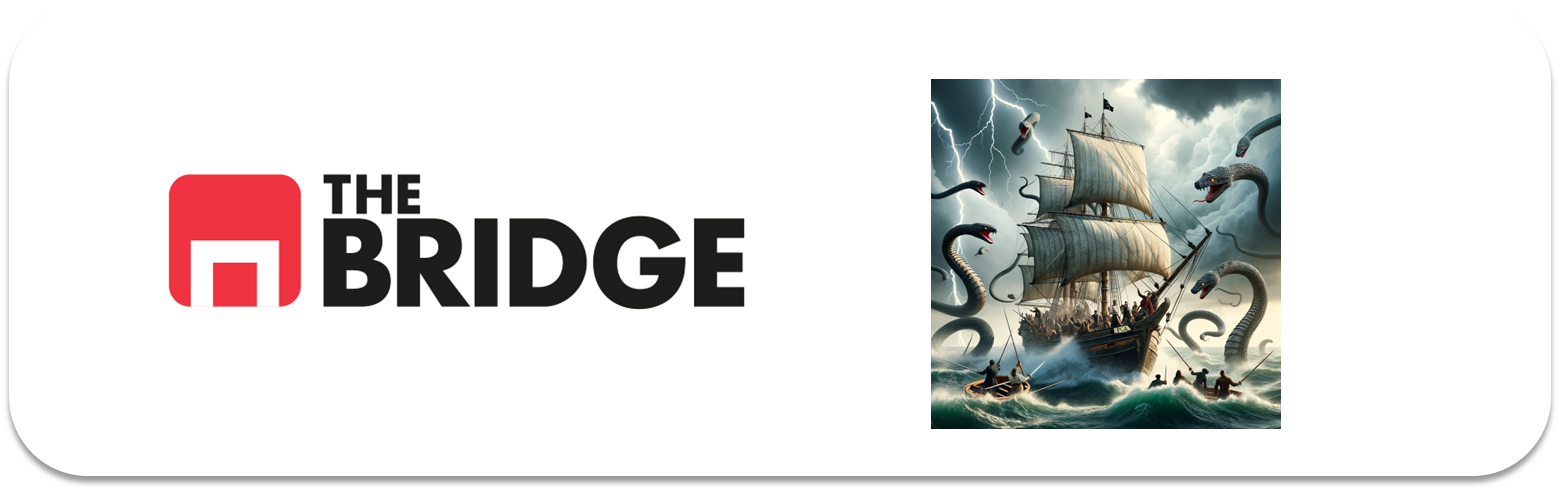

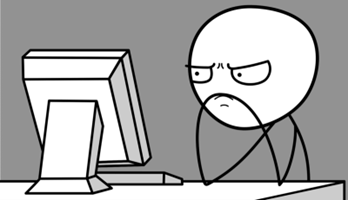

Para ejercitarte y afianzar lo aprendido sobre **PCA**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)

La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

# Principal Components Analysis: Nutrition
En esta colección de ejercicios no vas a montar ningún modelo de Machine Learning supervisado, sino que vas a practicar con PCA: pretratar el dato antes de calcular sus PCs, interpretarlas, pintar y escoger número de componentes según varianza.


### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


### Ejercicio 1: Importa los datos
1. Importa los datos: *nutrition.csv*
2. Observa las columnas que hay, así como su tipo.

In [19]:
df = pd.read_csv("./data/nutrition.csv")
df.head()

,ID,FoodGroup,ShortDescrip,Descrip,CommonName,MfgName,ScientificName,Energy_kcal,Protein_g,Fat_g,...,Folate_USRDA,Niacin_USRDA,Riboflavin_USRDA,Thiamin_USRDA,Calcium_USRDA,Copper_USRDA,Magnesium_USRDA,Phosphorus_USRDA,Selenium_USRDA,Zinc_USRDA
0,1001,Dairy and Egg Products,"BUTTER,WITH SALT","Butter, salted",NaN,NaN,NaN,717.0,0.85,81.11,...,0.0075,0.002625,0.026154,0.004167,0.020000,0.000000,0.004762,0.034286,0.018182,0.008182
1,1002,Dairy and Egg Products,"BUTTER,WHIPPED,WITH SALT","Butter, whipped, with salt",NaN,NaN,NaN,717.0,0.85,81.11,...,0.0075,0.002625,0.026154,0.004167,0.020000,0.000018,0.004762,0.032857,0.018182,0.004545
2,1003,Dairy and Egg Products,"BUTTER OIL,ANHYDROUS","Butter oil, anhydrous",NaN,NaN,NaN,876.0,0.28,99.48,...,0.0000,0.000188,0.003846,0.000833,0.003333,0.000001,0.000000,0.004286,0.000000,0.000909
3,1004,Dairy and Egg Products,"CHEESE,BLUE","Cheese, blue",NaN,NaN,NaN,353.0,21.40,28.74,...,0.0900,0.063500,0.293846,0.024167,0.440000,0.000044,0.054762,0.552857,0.263636,0.241818
4,1005,Dairy and Egg Products,"CHEESE,BRICK","Cheese, brick",NaN,NaN,NaN,371.0,23.24,29.68,...,0.0500,0.007375,0.270000,0.011667,0.561667,0.000027,0.057143,0.644286,0.263636,0.236364


In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8618 entries, 0 to 8617
Data columns (total 45 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                8618 non-null   int64  
 1   FoodGroup         8618 non-null   str    
 2   ShortDescrip      8618 non-null   str    
 3   Descrip           8618 non-null   str    
 4   CommonName        1063 non-null   str    
 5   MfgName           1560 non-null   str    
 6   ScientificName    732 non-null    str    
 7   Energy_kcal       8618 non-null   float64
 8   Protein_g         8618 non-null   float64
 9   Fat_g             8618 non-null   float64
 10  Carb_g            8618 non-null   float64
 11  Sugar_g           8618 non-null   float64
 12  Fiber_g           8618 non-null   float64
 13  VitA_mcg          8618 non-null   float64
 14  VitB6_mg          8618 non-null   float64
 15  VitB12_mcg        8618 non-null   float64
 16  VitC_mg           8618 non-null   float64
 17  VitE_m

### Ejercicio 2


Analiza la correlación entre las variables numéricas. 

In [21]:
num_cols = df.select_dtypes(include="number").columns.to_list()
num_cols = [col for col in num_cols if col != "ID"]
num_cols

['Energy_kcal',
 'Protein_g',
 'Fat_g',
 'Carb_g',
 'Sugar_g',
 'Fiber_g',
 'VitA_mcg',
 'VitB6_mg',
 'VitB12_mcg',
 'VitC_mg',
 'VitE_mg',
 'Folate_mcg',
 'Niacin_mg',
 'Riboflavin_mg',
 'Thiamin_mg',
 'Calcium_mg',
 'Copper_mcg',
 'Iron_mg',
 'Magnesium_mg',
 'Manganese_mg',
 'Phosphorus_mg',
 'Selenium_mcg',
 'Zinc_mg',
 'VitA_USRDA',
 'VitB6_USRDA',
 'VitB12_USRDA',
 'VitC_USRDA',
 'VitE_USRDA',
 'Folate_USRDA',
 'Niacin_USRDA',
 'Riboflavin_USRDA',
 'Thiamin_USRDA',
 'Calcium_USRDA',
 'Copper_USRDA',
 'Magnesium_USRDA',
 'Phosphorus_USRDA',
 'Selenium_USRDA',
 'Zinc_USRDA']

In [22]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Energy_kcal,8618.0,226.438617,169.388910,0.0,93.000000,191.000000,336.000000,902.000000
Protein_g,8618.0,11.523910,10.550590,0.0,2.470000,8.285000,19.977500,88.320000
Fat_g,8618.0,10.647024,15.866353,0.0,0.992500,5.235000,13.900000,100.000000
Carb_g,8618.0,21.819062,27.239000,0.0,0.040000,8.945000,32.900000,100.000000
Sugar_g,8618.0,6.560253,13.602098,0.0,0.000000,0.370000,5.300000,99.800000
Fiber_g,8618.0,2.023242,4.313670,0.0,0.000000,0.300000,2.400000,79.000000
VitA_mcg,8618.0,93.968786,779.362205,0.0,0.000000,1.500000,21.000000,30000.000000
VitB6_mg,8618.0,0.264369,0.478614,0.0,0.034250,0.120000,0.355000,12.000000
VitB12_mcg,8618.0,1.225260,4.319183,0.0,0.000000,0.080000,1.297500,98.890000
VitC_mg,8618.0,7.925377,57.582758,0.0,0.000000,0.000000,2.500000,2400.000000


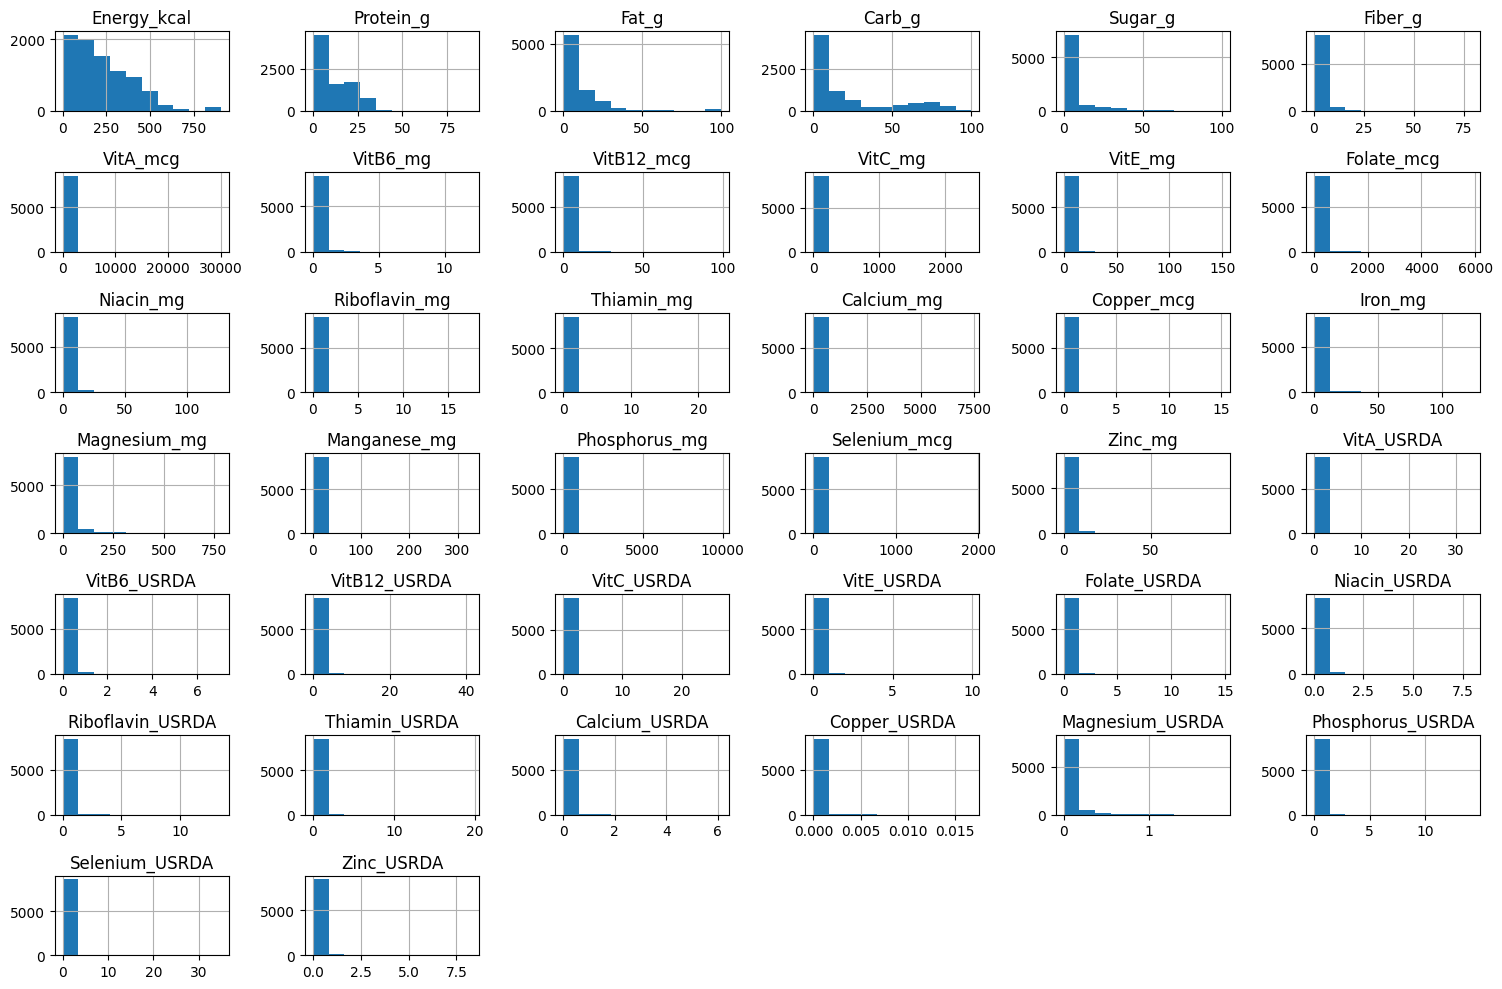

In [23]:
df[num_cols].hist(figsize=(15, 10))
plt.tight_layout()
plt.show();

In [24]:
corr = df[num_cols].corr()

corr.head()

,Energy_kcal,Protein_g,Fat_g,Carb_g,Sugar_g,Fiber_g,VitA_mcg,VitB6_mg,VitB12_mcg,VitC_mg,...,Folate_USRDA,Niacin_USRDA,Riboflavin_USRDA,Thiamin_USRDA,Calcium_USRDA,Copper_USRDA,Magnesium_USRDA,Phosphorus_USRDA,Selenium_USRDA,Zinc_USRDA
Energy_kcal,1.000000,0.110302,0.806795,0.487096,0.313151,0.197338,0.026329,0.121872,-0.012292,-0.033495,...,0.145936,0.174991,0.155830,0.187439,0.123571,0.099513,0.255880,0.195181,0.056673,0.112766
Protein_g,0.110302,1.000000,0.054715,-0.301974,-0.266170,-0.072777,0.026483,0.228485,0.245423,-0.066456,...,0.008939,0.376939,0.202480,0.098360,0.046888,0.158900,0.218611,0.444608,0.378369,0.416315
Fat_g,0.806795,0.054715,1.000000,-0.054116,-0.001962,-0.028842,0.024379,-0.046950,-0.020786,-0.059993,...,-0.058049,-0.022671,-0.036286,-0.005785,0.015039,0.042765,0.070781,0.066086,0.037559,0.028264
Carb_g,0.487096,-0.301974,-0.054116,1.000000,0.615344,0.458192,0.001871,0.195571,-0.094636,0.076745,...,0.325170,0.173285,0.232408,0.281809,0.189106,0.062106,0.287207,0.073180,-0.114600,-0.012187
Sugar_g,0.313151,-0.266170,-0.001962,0.615344,1.000000,0.115916,0.010143,0.088767,-0.050450,0.064152,...,0.161257,0.034378,0.125225,0.097751,0.129540,-0.005837,0.041308,-0.049784,-0.123708,-0.021991


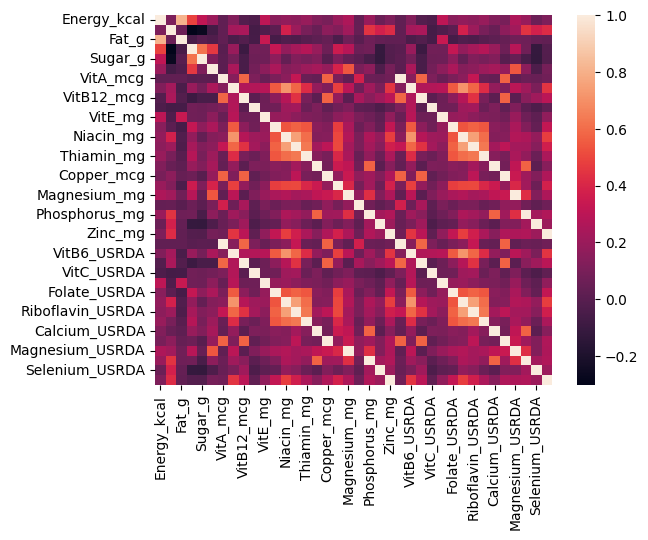

In [25]:
sns.heatmap(corr)
plt.show();

### Ejercicio 3

¿Qué pasa con las columnas USRDA? ¿Hay que tomar alguna decisión?

In [26]:
# Las columnas de USRDA tienen una correlación muy alta con las de los nutrientes (multicolinealidad)
# Esto crea información redundante, lo que puede afectar negativamente a los modelos de machine learning

In [27]:
# Yo me quedaría con las columnas de USRDA ya que montaremos un PCA, que se encargará de reducir la dimensionalidad y multicolinealidad

### Ejercicio 4: Variables Categóricas

Podríamos analizar las variables no numéricas del dataset e intentar obtener más información, pero por simplicidad en este caso procedemos a eliminarlas. Elimina las variables de texto del dataset.

In [28]:
df

,ID,FoodGroup,ShortDescrip,Descrip,CommonName,MfgName,ScientificName,Energy_kcal,Protein_g,Fat_g,...,Folate_USRDA,Niacin_USRDA,Riboflavin_USRDA,Thiamin_USRDA,Calcium_USRDA,Copper_USRDA,Magnesium_USRDA,Phosphorus_USRDA,Selenium_USRDA,Zinc_USRDA
0,1001,Dairy and Egg Products,"BUTTER,WITH SALT","Butter, salted",NaN,NaN,NaN,717.0,0.85,81.11,...,0.0075,0.002625,0.026154,0.004167,0.020000,0.000000,0.004762,0.034286,0.018182,0.008182
1,1002,Dairy and Egg Products,"BUTTER,WHIPPED,WITH SALT","Butter, whipped, with salt",NaN,NaN,NaN,717.0,0.85,81.11,...,0.0075,0.002625,0.026154,0.004167,0.020000,0.000018,0.004762,0.032857,0.018182,0.004545
2,1003,Dairy and Egg Products,"BUTTER OIL,ANHYDROUS","Butter oil, anhydrous",NaN,NaN,NaN,876.0,0.28,99.48,...,0.0000,0.000188,0.003846,0.000833,0.003333,0.000001,0.000000,0.004286,0.000000,0.000909
3,1004,Dairy and Egg Products,"CHEESE,BLUE","Cheese, blue",NaN,NaN,NaN,353.0,21.40,28.74,...,0.0900,0.063500,0.293846,0.024167,0.440000,0.000044,0.054762,0.552857,0.263636,0.241818
4,1005,Dairy and Egg Products,"CHEESE,BRICK","Cheese, brick",NaN,NaN,NaN,371.0,23.24,29.68,...,0.0500,0.007375,0.270000,0.011667,0.561667,0.000027,0.057143,0.644286,0.263636,0.236364
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8613,83110,Finfish and Shellfish Products,"MACKEREL,SALTED","Fish, mackerel, salted",NaN,NaN,NaN,305.0,18.50,25.10,...,0.0375,0.206250,0.146154,0.016667,0.055000,0.000111,0.142857,0.362857,1.334545,0.100000
8614,90240,Finfish and Shellfish Products,"SCALLOP,(BAY&SEA),CKD,STMD","Mollusks, scallop, (bay and sea), cooked, steamed",NaN,NaN,NaN,111.0,20.54,0.84,...,0.0500,0.067250,0.018462,0.010000,0.008333,0.000037,0.088095,0.608571,0.394545,0.140909
8615,90480,Sweets,"SYRUP,CANE","Syrup, Cane",NaN,NaN,NaN,269.0,0.00,0.00,...,0.0000,0.006250,0.046154,0.108333,0.010833,0.000022,0.023810,0.011429,0.012727,0.017273
8616,90560,Finfish and Shellfish Products,"SNAIL,RAW","Mollusks, snail, raw",NaN,NaN,NaN,90.0,16.10,1.40,...,0.0150,0.087500,0.092308,0.008333,0.008333,0.000444,0.595238,0.388571,0.498182,0.090909


### Ejercicio 5: Distribuciones

Analiza la distribución de las variables/columnas/features restantes. Recuerda que PCA es altamente sensible a las escala, así que transforma aquellas variables que creas necesario antes de proceder a escalarlas.


In [29]:
cat_cols = df.select_dtypes(include=["object","category"]).columns
print(cat_cols)

Index(['FoodGroup', 'ShortDescrip', 'Descrip', 'CommonName', 'MfgName',
       'ScientificName'],
      dtype='str')


/var/folders/0g/ltyf2qv91t9_1979pghhp9fh0000gn/T/ipykernel_3419/3673800674.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object","category"]).columns


In [30]:
df[cat_cols].describe().T

,count,unique,top,freq
FoodGroup,8618,25,Beef Products,946
ShortDescrip,8618,8614,"BABYFOOD,MEAT,BF,STR",2
Descrip,8618,8618,"Butter, salted",1
CommonName,1063,443,hamburger,25
MfgName,1560,92,"Kellogg, Co.",540
ScientificName,732,469,Phaseolus vulgaris,20


In [33]:
df[cat_cols].isna().sum()

FoodGroup            0
ShortDescrip         0
Descrip              0
CommonName        7555
MfgName           7058
ScientificName    7886
dtype: int64

In [34]:
X = df[num_cols]

labels = df[['FoodGroup', 'ShortDescrip', 'Descrip']]

### Ejercicio 6: Estandarizado
Estandariza cada variable. (No es necesario que dividas en train y test por simplificar).

In [35]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

### Ejercicio 7: Implementación del PCA
Prueba a montar un PCA con todos los componentes. Para ello utiliza los datos previamente transformados y escalados.

In [36]:
from sklearn.decomposition import PCA

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

### Ejercicio 8

Muestra en un dataframe la relación de cada componente con cada feature. En general, este paso no lo haremos salvo que sea necesario a posteriori explicar la influencia de alguna componente en función de las features originales, pero ahora, muéstralas.

In [38]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.components_.shape[0])],
    index=X.columns
)

loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC29,PC30,PC31,PC32,PC33,PC34,PC35,PC36,PC37,PC38
Energy_kcal,0.093260,-0.107176,0.145460,-0.149726,0.368909,-0.057590,-0.103243,0.290620,0.092876,0.356498,...,-0.000000e+00,-8.190376e-14,0.000000e+00,-0.000000e+00,-0.000000e+00,-0.000000e+00,-0.000000e+00,-0.000000e+00,0.000000e+00,-0.000000e+00
Protein_g,0.110906,0.121813,0.149082,0.346201,0.034279,0.032767,0.027833,-0.002977,-0.109394,0.207870,...,-2.702968e-16,2.176518e-14,-3.528874e-16,-2.402638e-16,1.681846e-15,4.805276e-16,1.051154e-15,-2.468218e-15,1.186302e-15,-1.404041e-15
Fat_g,0.013142,-0.017774,0.136413,-0.076802,0.439537,0.074793,-0.176196,0.200649,-0.097304,0.324270,...,-2.103146e-17,6.824659e-14,-2.924786e-17,-2.585512e-17,-6.514219e-16,-2.490306e-16,-2.493840e-16,9.080383e-16,-3.731276e-16,5.638400e-16
Carb_g,0.098943,-0.207495,0.009074,-0.293740,-0.013825,-0.196217,0.084550,0.189213,0.314505,0.046345,...,-1.247503e-16,5.275115e-14,7.056622e-16,6.658836e-16,2.352394e-15,5.518394e-16,7.621245e-16,-2.781227e-15,1.715284e-15,-2.160779e-15
Sugar_g,0.038806,-0.136635,-0.037849,-0.251270,0.016922,-0.109763,-0.066932,0.173473,0.485823,0.081555,...,2.054602e-16,-4.114628e-16,-7.409964e-16,-5.933691e-16,-1.139268e-15,-2.906590e-17,-1.975680e-16,1.429405e-15,-1.261554e-15,1.401410e-15
Fiber_g,0.112393,-0.141664,0.138136,-0.205899,-0.025736,-0.081862,0.317901,-0.060312,-0.007412,-0.124160,...,-9.847025e-17,-3.449695e-15,-1.499801e-16,-2.593528e-16,1.294665e-17,5.172020e-17,2.901485e-16,-6.249066e-16,2.463280e-16,-5.035131e-17
VitA_mcg,0.109097,0.338184,-0.063989,-0.247484,-0.036248,0.020855,-0.086161,0.056885,-0.055642,-0.043153,...,-2.833010e-02,9.240346e-02,3.013745e-01,-4.960567e-02,-9.038701e-02,-3.254282e-02,-1.123101e-03,2.777765e-01,-7.345154e-02,-3.771987e-02
VitB6_mg,0.240479,-0.083039,-0.123038,0.067578,0.009669,0.164281,0.031202,-0.113926,0.103492,-0.058795,...,6.359163e-02,2.578275e-01,1.809129e-01,1.247407e-01,9.424925e-02,-1.049478e-01,1.514986e-01,2.199304e-01,8.328482e-02,-1.991146e-01
VitB12_mcg,0.147756,0.359417,-0.066177,-0.029753,0.014009,-0.018807,-0.100115,-0.030154,0.104117,-0.031206,...,-1.045940e-01,5.532755e-02,3.252752e-01,-1.206412e-01,1.925538e-01,1.186789e-01,-2.374860e-02,9.184349e-03,1.359884e-01,3.736405e-01
VitC_mg,0.070302,-0.051780,-0.086169,-0.118719,-0.218295,0.535416,0.129593,0.179636,0.016150,0.145443,...,-3.163504e-01,1.211454e-01,9.891478e-02,-5.810297e-02,-1.042846e-01,1.714857e-01,1.427149e-01,-2.358012e-01,-7.308697e-02,4.857422e-03


### Ejercicio 9: Aportación de cada PCA
Visualiza en un diagrama de líneas la suma acumulada de la varianza explicativa del PCA.

Si tuviéses que quedarte con 70-75 % de la varianza original, ¿con cuántos Principal Components te quedarías?

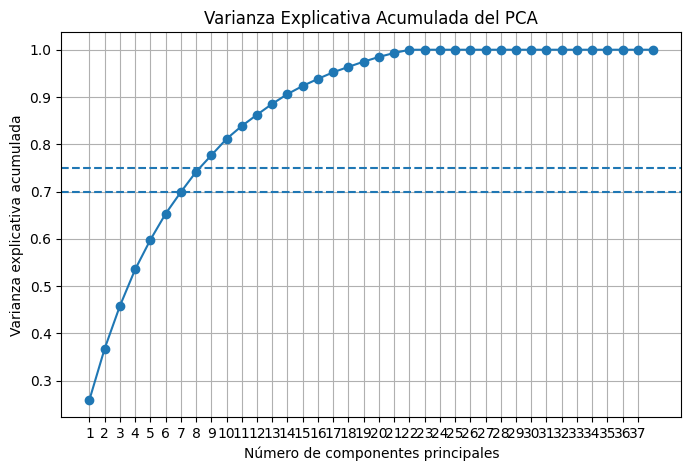

In [39]:
cum_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker = "o")
plt.axhline(y=0.70,linestyle='--')
plt.axhline(y=0.75, linestyle='--')
plt.xlabel("Número de componentes principales")
plt.ylabel("Varianza explicativa acumulada")
plt.title("Varianza Explicativa Acumulada del PCA")
plt.xticks(range(1, len(cum_var + 1)))
plt.grid(True)
plt.show;

In [ ]:
# Para conservar entre el 70 % y el 75 % de la varianza original, me quedaría con 7 u 8 componentes principales, 
# ya que a partir de ese punto la varianza explicativa acumulada entra en ese rango.

### Ejercicio 10: Reducción de features

Crea un nuevo PCA con X Principal Components, siendo X la cantidad de PC escogidos en el apartado anterior.

Obtén el nuevo dataset con el mismo número de registros que el original, pero en este caso con X features, que representan los PC elegidos.

In [40]:
pca_8 = PCA(n_components=8)
X_pca_8 = pca_8.fit_transform(X_scaled)

df_pca_8 = pd.DataFrame(
    X_pca_8,
    columns=[f'PC{i+1}' for i in range(8)],
    index=df.index
)

df_pca_8

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
0,-1.811468,0.244360,0.358148,-1.705050,3.521139,0.552613,-1.680265,1.475408
1,-1.806892,0.251895,0.361289,-1.722863,3.519338,0.545058,-1.667116,1.477944
2,-1.788169,0.230042,0.503071,-2.111154,4.540671,0.657578,-1.953727,1.945396
3,0.404461,0.116966,2.611367,0.508961,-0.618369,0.435269,-2.658160,0.128548
4,0.443959,0.118445,3.476585,0.350402,-0.985125,0.472345,-3.301049,0.167361
...,...,...,...,...,...,...,...,...
8613,1.043757,2.526914,1.181932,1.661541,1.329422,0.652453,-0.109771,1.632799
8614,-0.819215,0.819225,1.250838,1.359015,-0.718280,0.087358,-0.093824,-0.152917
8615,-1.696311,-1.327648,-0.934428,-2.552526,-0.101841,-1.316227,-0.172453,1.181518
8616,0.699677,0.080787,3.054021,-0.119478,0.448425,0.499595,3.114522,-0.731586


In [41]:
pca_7 = PCA(n_components=7)
X_pca_7 = pca_7.fit_transform(X_scaled)

df_pca_7 = pd.DataFrame(
    X_pca_7,
    columns=[f'PC{i+1}' for i in range(7)],
    index=df.index
)

df_pca_7

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
0,-1.811468,0.244360,0.358148,-1.705050,3.521139,0.552613,-1.680265
1,-1.806892,0.251895,0.361289,-1.722863,3.519338,0.545058,-1.667116
2,-1.788169,0.230042,0.503071,-2.111154,4.540671,0.657578,-1.953727
3,0.404461,0.116966,2.611367,0.508961,-0.618369,0.435269,-2.658160
4,0.443959,0.118445,3.476585,0.350402,-0.985125,0.472345,-3.301049
...,...,...,...,...,...,...,...
8613,1.043757,2.526914,1.181932,1.661541,1.329422,0.652453,-0.109771
8614,-0.819215,0.819225,1.250838,1.359015,-0.718280,0.087358,-0.093824
8615,-1.696311,-1.327648,-0.934428,-2.552526,-0.101841,-1.316227,-0.172453
8616,0.699677,0.080787,3.054021,-0.119478,0.448425,0.499595,3.114522
